In [2]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Masukin The Shotgun dari diskusi kita sebelumnya
def generate_logspace_params(num_trials=100):
    q_exps = np.random.uniform(-5, -2, num_trials)
    r_exps = np.random.uniform(-4, -1, num_trials)
    
    trials = []
    for q, r in zip(10 ** q_exps, 10 ** r_exps):
        trials.append({"Q": round(q, 7), "R": round(r, 7)})
    return trials

# 2. Masukin The Hakim
def evaluate_bot_sanity(sharpe, max_drawdown, total_fee):
    PENALTY_DRAWDOWN = max_drawdown * 2.0
    PENALTY_TURNOVER = total_fee * 1.5
    return sharpe - PENALTY_DRAWDOWN - PENALTY_TURNOVER

print("Amunisi awal siap. Ngetes 5 peluru pertama:")
test_bullets = generate_logspace_params(5)
for b in test_bullets:
    print(b)

Amunisi awal siap. Ngetes 5 peluru pertama:
{'Q': np.float64(0.0049457), 'R': np.float64(0.0002204)}
{'Q': np.float64(0.0003681), 'R': np.float64(0.0535013)}
{'Q': np.float64(0.000481), 'R': np.float64(0.0005114)}
{'Q': np.float64(2.47e-05), 'R': np.float64(0.0001188)}
{'Q': np.float64(0.0049042), 'R': np.float64(0.0604696)}


In [3]:
print("Mulai simulasi perang palsu...")
params = generate_logspace_params(100)
results = []

for p in params:
    # Pura-puranya ini hasil dari engine backtest lo
    fake_sharpe = np.random.uniform(-1, 3) 
    fake_dd = np.random.uniform(0.01, 0.20)
    fake_fee = np.random.uniform(0.1, 0.5)
    
    # Masukin ke Hakim
    final_score = evaluate_bot_sanity(fake_sharpe, fake_dd, fake_fee)
    
    results.append({
        "Q": p["Q"],
        "R": p["R"],
        "Score": final_score
    })

df_results = pd.DataFrame(results)
print(f"Simulasi selesai. Dapet {len(df_results)} baris data.")
df_results.head()

Mulai simulasi perang palsu...
Simulasi selesai. Dapet 100 baris data.


,Q,R,Score
0,0.000532,0.017680,-1.268060
1,0.000012,0.043768,0.723683
2,0.000053,0.003472,-1.330038
3,0.000027,0.008174,2.464353
4,0.000058,0.000296,1.957241


/tmp/ipykernel_24506/1439990994.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df_results.pivot_table(


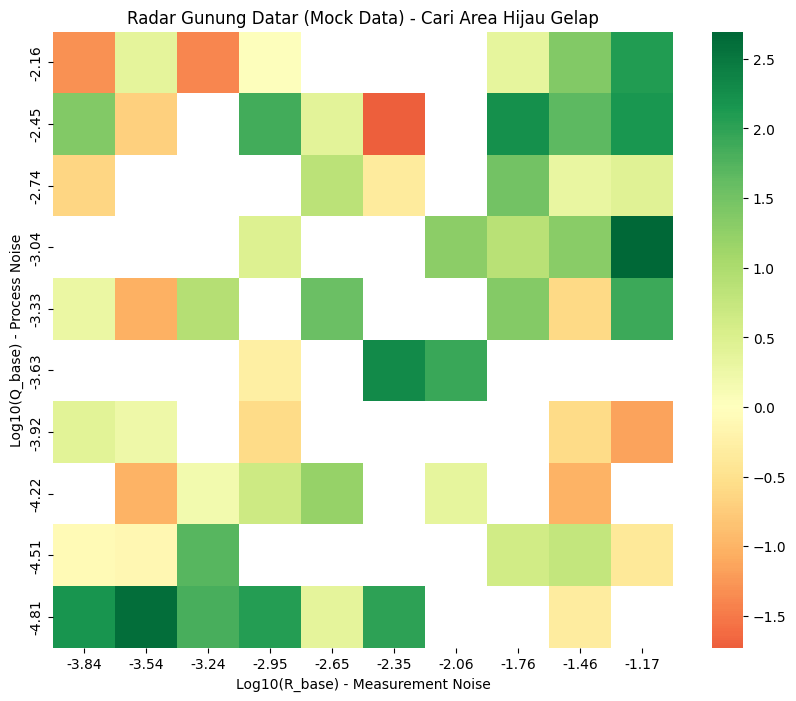

In [5]:
# Kelompokkan data Q dan R ke dalam grid logaritmik (misal 10x10)
df_results['Q_bin'] = pd.cut(np.log10(df_results['Q']), bins=10).apply(lambda x: round(x.mid, 2))
df_results['R_bin'] = pd.cut(np.log10(df_results['R']), bins=10).apply(lambda x: round(x.mid, 2))

# Bikin pivot table buat Heatmap
pivot_table = df_results.pivot_table(
    values='Score', 
    index='Q_bin', 
    columns='R_bin', 
    aggfunc='max' # Ambil skor tertinggi di area itu
)

# Plotting The Radar
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=False, cmap='RdYlGn', center=0)
plt.title("Radar Gunung Datar (Mock Data) - Cari Area Hijau Gelap")
plt.xlabel("Log10(R_base) - Measurement Noise")
plt.ylabel("Log10(Q_base) - Process Noise")
plt.gca().invert_yaxis() # Biar nilai Q kecil di bawah
plt.show()

In [16]:
import polars as pl

# 1. KUNCI KORDINAT ABSOLUT (Strict Globbing, No JSON allowed)
TARGET_ABSOLUT = "/home/bumip/orca/data/silver/*/*/*.parquet"

print(f"[*] Menembak kordinat: {TARGET_ABSOLUT}")

# 2. LOAD LAZY ENGINE DENGAN HIVE PARTITION
try:
    df_lazy = pl.scan_parquet(TARGET_ABSOLUT, hive_partitioning=True)
    skema = df_lazy.collect_schema().names()
    
    print("\n[+] BRANKAS DITEMUKAN DAN DIBOBOL!")
    print("--- 15 KOLOM PERTAMA ---")
    print(skema[:15])
    
    # 3. CONTOH PULLING DATA CEPAT (Ganti nama kolomnya nanti!)
    # print("\n[+] Narik data sample Januari 2024...")
    # sample = df_lazy.filter((pl.col("year") == 2024) & (pl.col("month") == 1)).select([skema[0], skema[1], skema[2]]).head(5).collect()
    # print(sample)
    
except Exception as e:
    print(f"[-] FATAL ERROR: {e}")

[*] Menembak kordinat: /home/bumip/orca/data/silver/*/*/*.parquet

[+] BRANKAS DITEMUKAN DAN DIBOBOL!
--- 15 KOLOM PERTAMA ---
['timestamp', 'close_BTC', 'close_DOGE', 'log_BTC', 'log_DOGE', 'ret_BTC', 'ret_DOGE', 'vol_BTC_1h', 'vol_DOGE_1h', 'corr_DOGE_BTC_1h', 'vol_BTC_4h', 'vol_DOGE_4h', 'corr_DOGE_BTC_4h', 'vol_BTC_24h', 'vol_DOGE_24h']


In [17]:
import polars as pl

TARGET_ABSOLUT = "/home/bumip/orca/data/silver/*/*/*.parquet"

# Kita setup Lazy Engine
df_lazy = pl.scan_parquet(TARGET_ABSOLUT, hive_partitioning=True)

print("[*] Merakit Radar Stat-Arb DOGE vs BTC...")

# 1. TEMBAK & FILTER DATA (Contoh: Tarik Januari 2024 aja biar RAM lu aman)
df_signal = (
    df_lazy
    .filter((pl.col("year") == 2024) & (pl.col("month") == 1))
    
    # 2. PRUNING: Cuma ambil kolom yang bikin cuan
    .select([
        "timestamp", "log_BTC", "log_DOGE", "corr_DOGE_BTC_4h", "vol_DOGE_4h"
    ])
    
    # 3. BIKIN INDIKATOR SPREAD (Selisih Log Price)
    .with_columns([
        (pl.col("log_DOGE") - pl.col("log_BTC")).alias("spread")
    ])
    
    # 4. BIKIN Z-SCORE SPREAD (Rolling 24 Jam - Asumsi 1 candle = 1 menit, 24h = 1440)
    # Kalau data lu 1h, ganti window size-nya jadi 24
    .with_columns([
        ((pl.col("spread") - pl.col("spread").rolling_mean(window_size=1440)) / 
         pl.col("spread").rolling_std(window_size=1440)).alias("z_score")
    ])
    
    # 5. TRIGGER ACTION: Cari momen di mana spread abnormal (Z > 2 atau Z < -2) 
    # DAN korelasi lagi melemah (di bawah 0.5)
    .filter(
        (pl.col("z_score").abs() > 2.0) & 
        (pl.col("corr_DOGE_BTC_4h") < 0.5)
    )
    .collect()
)

print(f"\n[+] KETEMU {len(df_signal)} TITIK ENTRY ARBITRASE!")
print(df_signal.select(["timestamp", "z_score", "corr_DOGE_BTC_4h"]).head(10))

[*] Merakit Radar Stat-Arb DOGE vs BTC...


ComputeError: cannot compare string with numeric type (i32)

In [19]:
import polars as pl
from datetime import datetime

# ================= KONFIGURASI =================
TARGET_ABSOLUT = "/home/bumip/orca/data/silver/*/*/*.parquet"
TAHUN = "2024"
BULAN = "01"          # karena folder 'month=01'
WINDOW_MINUTES = 1440  # 24 jam * 60 menit (asumsi data 1 menit)
Z_THRESHOLD = 2.0
CORR_THRESHOLD = 0.5   # korelasi maksimum untuk entry
MIN_PERIODS = 720      # minimal 12 jam data untuk rolling (setengah window)

# ================= EKSEKUSI =================
print("[*] Merakit Radar Stat-Arb DOGE vs BTC...")

# Scan dengan hive partitioning
df_lazy = pl.scan_parquet(TARGET_ABSOLUT, hive_partitioning=True)

# Validasi kolom yang diperlukan (opsional, agar error lebih jelas)
required_columns = ["timestamp", "log_BTC", "log_DOGE", "corr_DOGE_BTC_4h", "vol_DOGE_4h"]
missing = set(required_columns) - set(df_lazy.columns)
if missing:
    raise ValueError(f"Kolom berikut tidak ditemukan: {missing}")

# Proses utama
df_signal = (
    df_lazy
    .filter(
        (pl.col("year") == TAHUN) & 
        (pl.col("month") == BULAN)
    )
    .select(required_columns)
    .with_columns(
        (pl.col("log_DOGE") - pl.col("log_BTC")).alias("spread")
    )
    .with_columns(
        # Rolling z-score dengan handling null
        ((pl.col("spread") - pl.col("spread").rolling_mean(window_size=WINDOW_MINUTES, min_periods=MIN_PERIODS)) /
         pl.col("spread").rolling_std(window_size=WINDOW_MINUTES, min_periods=MIN_PERIODS))
        .alias("z_score")
    )
    .filter(
        (pl.col("z_score").abs() > Z_THRESHOLD) &
        (pl.col("corr_DOGE_BTC_4h") < CORR_THRESHOLD)
    )
    .select([
        "timestamp",
        "z_score",
        "corr_DOGE_BTC_4h",
        "vol_DOGE_4h",
        "spread"
    ])
    .collect(streaming=True)  # streaming untuk efisiensi memori
)

print(f"\n[+] KETEMU {len(df_signal)} TITIK ENTRY ARBITRASE!")
if df_signal.height > 0:
    print(df_signal.head(10))
else:
    print("[!] Tidak ada sinyal pada periode ini.")

[*] Merakit Radar Stat-Arb DOGE vs BTC...

[+] KETEMU 1135 TITIK ENTRY ARBITRASE!
shape: (10, 5)
┌─────────────────────┬───────────┬──────────────────┬─────────────┬────────────┐
│ timestamp           ┆ z_score   ┆ corr_DOGE_BTC_4h ┆ vol_DOGE_4h ┆ spread     │
│ ---                 ┆ ---       ┆ ---              ┆ ---         ┆ ---        │
│ datetime[ms]        ┆ f64       ┆ f64              ┆ f64         ┆ f64        │
╞═════════════════════╪═══════════╪══════════════════╪═════════════╪════════════╡
│ 2024-01-02 00:47:00 ┆ -2.723498 ┆ 0.499007         ┆ 0.000588    ┆ -13.085505 │
│ 2024-01-02 00:48:00 ┆ -2.877703 ┆ 0.496091         ┆ 0.000591    ┆ -13.086518 │
│ 2024-01-03 16:09:00 ┆ -3.151634 ┆ 0.427614         ┆ 0.005925    ┆ -13.172377 │
│ 2024-01-09 17:30:00 ┆ 2.02864   ┆ 0.416374         ┆ 0.002508    ┆ -13.251663 │
│ 2024-01-09 17:31:00 ┆ 3.503235  ┆ 0.315908         ┆ 0.002788    ┆ -13.230819 │
│ 2024-01-09 17:32:00 ┆ 2.260682  ┆ 0.292147         ┆ 0.003013    ┆ -13.248265 │
│

/tmp/ipykernel_24506/3572748661.py:21: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  missing = set(required_columns) - set(df_lazy.columns)
/tmp/ipykernel_24506/3572748661.py:38: DeprecationWarning: the argument `min_periods` for `Expr.rolling_mean` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  ((pl.col("spread") - pl.col("spread").rolling_mean(window_size=WINDOW_MINUTES, min_periods=MIN_PERIODS)) /
/tmp/ipykernel_24506/3572748661.py:39: DeprecationWarning: the argument `min_periods` for `Expr.rolling_std` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  pl.col("spread").rolling_std(window_size=WINDOW_MINUTES, min_periods=MIN_PERIODS))
/tmp/ipykernel_24506/3572748661.py:27: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.


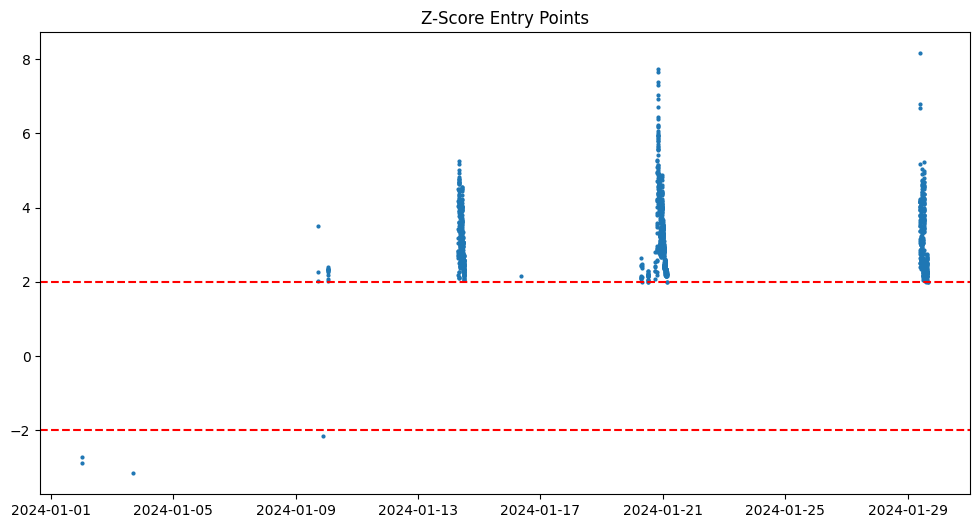

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(df_signal['timestamp'], df_signal['z_score'], 'o', markersize=2)
plt.axhline(Z_THRESHOLD, color='r', linestyle='--')
plt.axhline(-Z_THRESHOLD, color='r', linestyle='--')
plt.title('Z-Score Entry Points')
plt.show()

In [21]:
df_signal.write_csv("doge_btc_signals_202401.csv") 